In [13]:
# 1) Mount Drive once per session
from google.colab import drive
drive.mount('/content/drive')

# 2) Pick a *persistent* output path on Drive
import os
ZIP_PATH = "/content/drive/MyDrive/kaggle/CAFA6/cafa-6-protein-function-prediction.zip"
DATA_DIR = "/content/drive/MyDrive/kaggle/CAFA6/"
os.makedirs(DATA_DIR, exist_ok=True)
OUT = os.path.join(DATA_DIR, "submission_prior_anc_3sig.tsv.gz")
print("Will write to:", OUT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Will write to: /content/drive/MyDrive/kaggle/CAFA6/submission_prior_anc_3sig.tsv.gz


In [14]:
print(DATA_DIR)

/content/drive/MyDrive/kaggle/CAFA6/


In [8]:
# Basic imports
import os, re, io, gzip, time, gc
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


In [18]:
# Adjust this to where you unzipped the competition files

TRAIN_TERMS   = f"{DATA_DIR}/train_terms.tsv"
TRAIN_TAX     = f"{DATA_DIR}/train_taxonomy.tsv"
TRAIN_FASTA   = f"{DATA_DIR}/train_sequences.fasta"
TEST_FASTA    = f"{DATA_DIR}/testsuperset.fasta"
GO_OBO        = f"{DATA_DIR}/go-basic.obo"


In [19]:
def fasta_iter(path):
    """Yield (header, sequence) for a FASTA file."""
    with open(path) as fh:
        header, seq = None, []
        for line in fh:
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)
                header, seq = line.rstrip("\n"), []
            else:
                seq.append(line.strip())
        if header is not None:
            yield header, "".join(seq)

# Sanity check
h, s = next(fasta_iter(TEST_FASTA))
print("Example test header:", h[:100], "…  len:", len(s))


Example test header: >A0A0C5B5G6 9606 …  len: 16


In [20]:
# Load training labels and taxonomy
train_terms = pd.read_csv(TRAIN_TERMS, sep="\t", header=None, names=["entry","go_id","aspect"], dtype=str)
train_tax   = pd.read_csv(TRAIN_TAX,   sep="\t", header=None, names=["entry","taxid"], dtype=str)

# Fix any header-row-as-data issue
bad = (train_terms["entry"] == "EntryID") | (train_terms["go_id"] == "term")
train_terms = train_terms.loc[~bad].reset_index(drop=True)

# Map aspect codes to BPO/CCO/MFO
aspect_map = {
    "P":"BPO","C":"CCO","F":"MFO",
    "BP":"BPO","CC":"CCO","MF":"MFO",
    "BPO":"BPO","CCO":"CCO","MFO":"MFO"
}
train_terms["aspect"] = train_terms["aspect"].astype(str).map(aspect_map)
train_terms = train_terms.dropna(subset=["aspect"]).reset_index(drop=True)

print(train_terms["aspect"].value_counts())
print("train_terms:", train_terms.shape, "  train_tax:", train_tax.shape)


aspect
BPO    250805
CCO    157770
MFO    128452
Name: count, dtype: int64
train_terms: (537027, 3)   train_tax: (82404, 2)


In [21]:
# Build dict: entry -> amino-acid sequence (training)
seqs = {}
for h, s in fasta_iter(TRAIN_FASTA):
    m = re.search(r">\w+\|([^|]+)\|", h)
    entry = m.group(1) if m else h[1:].split()[0]
    seqs[entry] = s
print("Loaded train sequences:", len(seqs))


Loaded train sequences: 82404


In [22]:
from collections import defaultdict, Counter

def fit_taxon_prior(train_terms: pd.DataFrame, train_tax: pd.DataFrame, alpha=1.0, min_count=2):
    tax_aspect_counts = defaultdict(lambda: defaultdict(Counter))
    tax_aspect_n = defaultdict(lambda: defaultdict(int))
    aspect_counts_global = defaultdict(Counter)
    aspect_n_global = defaultdict(int)

    tt = train_terms.merge(train_tax, on="entry", how="inner")
    seen_entry_aspect = set()

    for _, (e,g,a,t) in tt[["entry","go_id","aspect","taxid"]].iterrows():
        tax_aspect_counts[t][a][g] += 1
        aspect_counts_global[a][g] += 1
        if (e,a) not in seen_entry_aspect:
            seen_entry_aspect.add((e,a))
            tax_aspect_n[t][a] += 1
            aspect_n_global[a]  += 1

    # drop ultra-rare within-tax terms
    for t in list(tax_aspect_counts):
        for a in list(tax_aspect_counts[t]):
            for term, c in list(tax_aspect_counts[t][a].items()):
                if c < min_count:
                    del tax_aspect_counts[t][a][term]

    return dict(tax_aspect_counts=tax_aspect_counts,
                tax_aspect_n=tax_aspect_n,
                aspect_counts_global=aspect_counts_global,
                aspect_n_global=aspect_n_global,
                alpha=alpha)

def score_taxon_prior_pairs(model, taxid, aspect, top_k=20):
    d = model["tax_aspect_counts"].get(taxid, {}).get(aspect)
    n = model["tax_aspect_n"].get(taxid, {}).get(aspect, 0)
    if not d or n == 0:
        d = model["aspect_counts_global"][aspect]; n = model["aspect_n_global"][aspect]
    V = max(1, len(d)); a = model["alpha"]
    scored = [(t, (c + a) / (n + a * V)) for t, c in d.items()]
    scored.sort(key=lambda x: -x[1])
    return scored[:top_k]


In [23]:
pri_full = fit_taxon_prior(train_terms=train_terms, train_tax=train_tax, alpha=1.0, min_count=2)
print("Prior fitted.")


Prior fitted.


In [19]:
!pip -q install obonet networkx
import obonet, networkx as nx

G = obonet.read_obo(GO_OBO)

# Parent lookup (include common hierarchical relations)
parents = {}
for n in G.nodes:
    pset = set()
    for u, v, k in G.in_edges(n, keys=True):
        rel = G.edges[u, v, k].get("relation") or G.edges[u, v, k].get("typedef")
        if rel in (None, "is_a", "part_of", "has_part", "occurs_in", "regulates",
                   "positively_regulates", "negatively_regulates"):
            pset.add(u)
    parents[n] = pset

def propagate_max(scores_dict):
    """Given term->score, add ancestors with max(child)."""
    out = dict(scores_dict)
    stack = list(scores_dict.keys())
    while stack:
        t = stack.pop()
        for par in parents.get(t, ()):
            new = max(out.get(par, 0.0), out[t])
            if new > out.get(par, 0.0):
                out[par] = new
                stack.append(par)
    return out

def three_sig(p: float) -> str:
    if p <= 0: p = 1e-6
    if p > 1:  p = 1.0
    s = f"{p:.3g}"
    return "0.001" if s == "0" else s


In [20]:
# Remove accidental header-like rows and duplicates
bad = (train_terms["entry"] == "EntryID") | (train_terms["go_id"] == "term")
train_terms = train_terms.loc[~bad].drop_duplicates(["entry","go_id","aspect"]).reset_index(drop=True)


In [21]:
# Build set of valid GO IDs from go-basic.obo
import obonet
G = obonet.read_obo(GO_OBO)
valid_terms = set(n for n in G.nodes if n.startswith("GO:"))

# Keep only valid terms
n0 = len(train_terms)
train_terms = train_terms[train_terms["go_id"].isin(valid_terms)].reset_index(drop=True)
print("Dropped invalid GO ids:", n0 - len(train_terms))


Dropped invalid GO ids: 0


In [22]:
aspect_map = {"P":"BPO","C":"CCO","F":"MFO","BP":"BPO","CC":"CCO","MF":"MFO","BPO":"BPO","CCO":"CCO","MFO":"MFO"}
train_terms["aspect"] = train_terms["aspect"].map(aspect_map)
print(train_terms["aspect"].value_counts(dropna=False))


aspect
BPO    250805
CCO    157770
MFO    128452
Name: count, dtype: int64


In [23]:
# entries with sequences
have_seq = set(seqs.keys())
n_seq = train_terms["entry"].isin(have_seq).sum()
print("Labeled rows whose entry has a sequence:", n_seq, "/", len(train_terms))

# per-aspect label counts
print(train_terms.groupby("aspect")["go_id"].nunique().rename("unique_terms_by_aspect"))

# term prevalence among training entries
from collections import Counter
Y_by_entry = train_terms.groupby("entry")["go_id"].apply(set)
n_entries = len(Y_by_entry)
cnt = Counter()
for s in Y_by_entry: cnt.update(s)
prev = pd.DataFrame({"go_id": list(cnt.keys()), "count": list(cnt.values())})
prev["prevalence"] = prev["count"] / n_entries
print(prev["prevalence"].describe())


Labeled rows whose entry has a sequence: 537027 / 537027
aspect
BPO    16858
CCO     2651
MFO     6616
Name: unique_terms_by_aspect, dtype: int64
count    26125.000000
mean         0.000249
std          0.003254
min          0.000012
25%          0.000024
50%          0.000049
75%          0.000146
max          0.409118
Name: prevalence, dtype: float64


In [24]:
tax_counts = train_tax["taxid"].value_counts()
print("taxa total:", tax_counts.size, " | rare taxa (<20 entries):", (tax_counts<20).sum())


taxa total: 1381  | rare taxa (<20 entries): 1301


In [25]:
IA = pd.read_csv(f"{DATA_DIR}/IA.tsv", sep="\t", header=None, names=["go_id","ia"])
ia_map = IA.set_index("go_id")["ia"].to_dict()
ia_max = max(ia_map.values()) or 1.0
def ia_adj(term, p, lam=0.08):
    ia = ia_map.get(term, 0.0) / ia_max
    return p * (1.0 + lam * ia)


In [26]:
def score_taxon_prior_pairs_shrunk(model, taxid, aspect, top_k=20, k=100, alpha=1.0):
    # counts
    tax_d = model["tax_aspect_counts"].get(taxid, {}).get(aspect, {})
    tax_n = model["tax_aspect_n"].get(taxid, {}).get(aspect, 0)
    glob_d = model["aspect_counts_global"][aspect]
    glob_n = model["aspect_n_global"][aspect]
    V = max(1, len(glob_d))  # vocab size from global
    # Laplace estimates
    def lap(d, n, term): return (d.get(term, 0) + alpha) / (n + alpha * V)
    w = tax_n / (tax_n + k) if tax_n else 0.0
    # union of terms seen in taxon or global (use global keyset to avoid tiny tax vocab)
    terms = glob_d.keys() if not tax_d else set(glob_d.keys()) | set(tax_d.keys())
    scored = []
    for t in terms:
        p_tax  = lap(tax_d,  tax_n,  t)
        p_glob = lap(glob_d, glob_n, t)
        p = w * p_tax + (1 - w) * p_glob
        scored.append((t, p))
    # IA-aware sort
    scored.sort(key=lambda x: -ia_adj(x[0], x[1]))
    return scored[:top_k]


In [27]:
aspects = ("BPO","CCO","MFO")
TOPK_PRIOR = {"BPO": 25, "CCO": 15, "MFO": 20}

global_cache = {a: score_taxon_prior_pairs_shrunk(pri_full, None, a, top_k=TOPK_PRIOR[a])
                for a in aspects}

tax_cache = {}
for tx in train_tax["taxid"].unique():
    d = {}
    for a in aspects:
        lst = score_taxon_prior_pairs_shrunk(pri_full, tx, a, top_k=TOPK_PRIOR[a])
        d[a] = lst if lst else global_cache[a]
    tax_cache[tx] = d


In [28]:
import io, gzip, re, time
from tqdm.auto import tqdm

# Reuse from earlier:
# - TEST_FASTA, fasta_iter
# - aspects = ("BPO","CCO","MFO")
# - tax_cache, global_cache (from step 8)
# - propagate_max, three_sig (from step 7)

# Parse entry/taxon from header
_re_id = re.compile(r">\w+\|([^|]+)\|")
_re_tx = re.compile(r"taxon=(\d+)")
def parse_e_tx(h):
    m_id=_re_id.search(h); e=m_id.group(1) if m_id else h[1:].split()[0]
    m_tx=_re_tx.search(h); tx=int(m_tx.group(1)) if m_tx else None
    return e, tx

# Use the same top-k per aspect that you cached in step 8
CAPS = {"BPO": 25, "CCO": 15, "MFO": 20}

# Count for progress bar
N = sum(1 for _ in fasta_iter(TEST_FASTA))
OUT = "submission_prior_anc_3sig.tsv.gz"

t0 = time.perf_counter()
with gzip.open(OUT, "wt") as fout:
    buf = io.StringIO()
    with tqdm(total=N, desc="Prior+propagate+write", unit="prot") as pbar:
        for h, _ in fasta_iter(TEST_FASTA):
            e, tx = parse_e_tx(h)

            # Gather prior predictions per aspect from cache
            raw = {}
            cache = tax_cache.get(tx, {}) if tx in tax_cache else {}
            for a in aspects:
                pairs = cache.get(a) or global_cache[a]   # already IA-sorted in step 8 (if you added IA)
                for t, p in pairs[:CAPS[a]]:
                    if p > raw.get(t, 0.0):
                        raw[t] = p

            # Ontology-consistent ancestor closure (max over children)
            final_scores = propagate_max(raw)

            # Write rows (3 significant figures, (0,1])
            for t, p in final_scores.items():
                buf.write(f"{e}\t{t}\t{three_sig(p)}\n")

            # Flush ~2MB at a time for speed
            if buf.tell() > 2_000_000:
                fout.write(buf.getvalue()); buf.seek(0); buf.truncate(0)

            pbar.update(1)

    # Final flush
    if buf.tell():
        fout.write(buf.getvalue())

elapsed = time.perf_counter() - t0
print(f"Done. {OUT}  |  {elapsed/60:.1f} min")


Prior+propagate+write:   0%|          | 0/224309 [00:00<?, ?prot/s]

Done. submission_prior_anc_3sig.tsv.gz  |  155.3 min


In [3]:
import os, glob

print(glob.glob("submission_prior_anc_3sig.tsv.gz"))



[]


In [11]:
!ls -lh /content | grep submission_ || true


In [12]:
!ls -lh submission_prior_anc_3sig.tsv.gz


ls: cannot access 'submission_prior_anc_3sig.tsv.gz': No such file or directory


In [16]:
%pip -q install obonet networkx


In [24]:
# Build set of valid GO IDs from go-basic.obo
import obonet
G = obonet.read_obo(GO_OBO)
valid_terms = set(n for n in G.nodes if n.startswith("GO:"))

# Keep only valid terms
n0 = len(train_terms)
train_terms = train_terms[train_terms["go_id"].isin(valid_terms)].reset_index(drop=True)
print("Dropped invalid GO ids:", n0 - len(train_terms))

Dropped invalid GO ids: 0


In [26]:
# === Smaller, faster submission writer (NO local propagation; dynamic caps) ===
# Assumes you already have:
# - DATA_DIR, TEST_FASTA, fasta_iter
# - aspects = ("BPO","CCO","MFO")
# - tax_cache, global_cache  (from your prior cache step)
# If not, re-run your prior-building cells first.

import os, re, io, gzip, time
import pandas as pd
from tqdm.auto import tqdm

# Paths (reuse your Drive folder; adjust if needed)
DATA_DIR  = DATA_DIR if 'DATA_DIR' in globals() else "/content/drive/MyDrive/kaggle/CAFA6"
TEST_FASTA = TEST_FASTA if 'TEST_FASTA' in globals() else f"{DATA_DIR}/testsuperset.fasta"
TRAIN_TAX  = f"{DATA_DIR}/train_taxonomy.tsv"
OUT        = os.path.join(DATA_DIR, "submission_prior_NOprop_3sig.tsv.gz")
print("Will write to:", OUT)

# Parse entry/taxon from test headers
_re_id = re.compile(r">\w+\|([^|]+)\|")
_re_tx = re.compile(r"taxon=(\d+)")
def parse_e_tx(h):
    m_id=_re_id.search(h); e=m_id.group(1) if m_id else h[1:].split()[0]
    m_tx=_re_tx.search(h); tx=int(m_tx.group(1)) if m_tx else None
    return e, tx

# 3-sig formatter, (0,1] clamp
def three_sig(p):
    if p <= 0: p = 1e-6
    if p > 1:  p = 1.0
    s = f"{p:.3g}"
    return "0.001" if s == "0" else s

# Dynamic caps: smaller for rare taxa to reduce noise/rows
RARE_THRESH = 20  # taxa with <20 train proteins are "rare"
CAPS_COMMON = {"BPO": 20, "CCO": 12, "MFO": 15}
CAPS_RARE   = {"BPO": 15, "CCO": 10, "MFO": 12}

# Build taxon sizes to decide rare/common
tax = pd.read_csv(TRAIN_TAX, sep="\t", header=None, names=["entry","taxid"], dtype=str)
tax_sizes = tax["taxid"].value_counts().to_dict()

def choose_caps(tx):
    n = tax_sizes.get(str(tx), 0) if tx is not None else 0
    return CAPS_RARE if n < RARE_THRESH else CAPS_COMMON

# Count test proteins for progress
N = sum(1 for _ in fasta_iter(TEST_FASTA))

t0 = time.perf_counter()
with gzip.open(OUT, "wt") as fout:
    buf = io.StringIO()
    with tqdm(total=N, desc="Prior(NO-prop)+write", unit="prot") as pbar:
        for h, _ in fasta_iter(TEST_FASTA):
            e, tx = parse_e_tx(h)
            caps = choose_caps(tx)

            # Collect top terms per aspect from cache (already IA-ranked if you added IA earlier)
            out_terms = {}  # term -> prob (max if seen twice)
            cache = tax_cache.get(tx, {}) if tx in tax_cache else {}
            for a in aspects:
                pairs = cache.get(a) or global_cache[a]
                for t, p in pairs[:caps[a]]:
                    if p > out_terms.get(t, 0.0):
                        out_terms[t] = p

            # NO local propagation here — organizers will propagate during evaluation
            for t, p in out_terms.items():
                buf.write(f"{e}\t{t}\t{three_sig(p)}\n")

            # Flush ~2MB to keep data safely on Drive
            if buf.tell() > 2_000_000:
                fout.write(buf.getvalue()); buf.seek(0); buf.truncate(0)

            pbar.update(1)

    # Final flush
    if buf.tell():
        fout.write(buf.getvalue())

elapsed = time.perf_counter() - t0
print(f"Done. {OUT}  |  {elapsed/60:.1f} min")


Will write to: /content/drive/MyDrive/kaggle/CAFA6/submission_prior_NOprop_3sig.tsv.gz


Prior(NO-prop)+write:   0%|          | 0/224309 [00:00<?, ?prot/s]

Done. /content/drive/MyDrive/kaggle/CAFA6/submission_prior_NOprop_3sig.tsv.gz  |  1.2 min


In [27]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- paths (adjust if needed) ---
DATA_DIR   = "/content/drive/MyDrive/kaggle/CAFA6"
TRAIN_TERMS = f"{DATA_DIR}/train_terms.tsv"
TRAIN_TAX   = f"{DATA_DIR}/train_taxonomy.tsv"
TRAIN_FASTA = f"{DATA_DIR}/train_sequences.fasta"
IA_PATH     = f"{DATA_DIR}/IA.tsv"

# --- load core tables ---
terms = pd.read_csv(TRAIN_TERMS, sep="\t", header=None, names=["entry","go_id","aspect"], dtype=str)
tax   = pd.read_csv(TRAIN_TAX,   sep="\t", header=None, names=["entry","taxid"], dtype=str)

# clean aspect codes
aspect_map = {"P":"BPO","C":"CCO","F":"MFO","BP":"BPO","CC":"CCO","MF":"MFO","BPO":"BPO","CCO":"CCO","MFO":"MFO"}
terms = terms[(terms["entry"]!="EntryID") & (terms["go_id"]!="term")].drop_duplicates()
terms["aspect"] = terms["aspect"].map(aspect_map)

# --- fast sequence length lookup from FASTA (only for sampled entries later) ---
def fasta_iter(path):
    with open(path) as fh:
        h, seq = None, []
        for line in fh:
            if line.startswith(">"):
                if h is not None:
                    yield h, "".join(seq)
                h, seq = line.strip(), []
            else:
                seq.append(line.strip())
        if h is not None:
            yield h, "".join(seq)

seq_len_map = {}
for h, s in fasta_iter(TRAIN_FASTA):
    m = re.search(r">\w+\|([^|]+)\|", h)
    entry = m.group(1) if m else h[1:].split()[0]
    seq_len_map[entry] = len(s)

# --- stratified tiny subset: K taxa × N per taxon ---
K_TAXA = 5
N_PER_TAX = 200

top_taxa = tax["taxid"].value_counts().head(50).index.tolist()  # pick among larger taxa to ensure labels
chosen_taxa = top_taxa[:K_TAXA]
subset_entries = (
    tax[tax["taxid"].isin(chosen_taxa)]
    .groupby("taxid", group_keys=False)
    .apply(lambda g: g.sample(min(N_PER_TAX, len(g)), random_state=42))
    ["entry"]
    .tolist()
)

mini_terms = terms[terms["entry"].isin(subset_entries)].copy()
mini_tax   = tax[tax["entry"].isin(subset_entries)].copy()

# add helpers
mini_terms["seq_len"] = mini_terms["entry"].map(seq_len_map)
labels_per_entry = mini_terms.groupby("entry")["go_id"].nunique()
mini_tax = mini_tax.assign(labels=mini_tax["entry"].map(labels_per_entry))

print(f"Subset: entries={mini_tax['entry'].nunique()}, labels={len(mini_terms)}, unique terms={mini_terms['go_id'].nunique()}")


Subset: entries=1000, labels=7647, unique terms=3479


/tmp/ipython-input-2791676724.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(N_PER_TAX, len(g)), random_state=42))


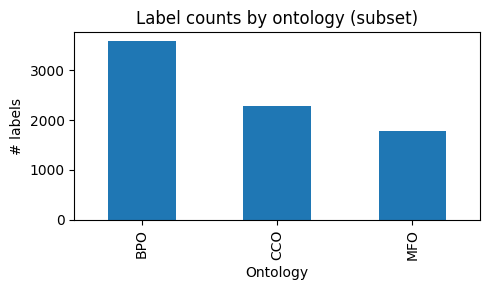

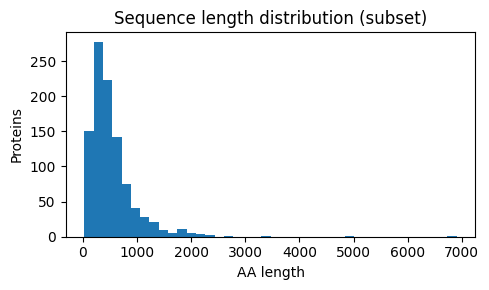

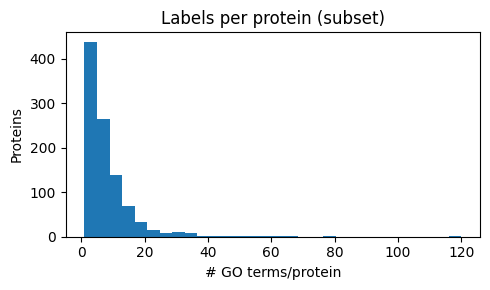

In [28]:
# Aspect mix
plt.figure(figsize=(5,3))
mini_terms["aspect"].value_counts().plot(kind="bar")
plt.title("Label counts by ontology (subset)")
plt.xlabel("Ontology"); plt.ylabel("# labels")
plt.tight_layout(); plt.show()

# Sequence length distribution
plt.figure(figsize=(5,3))
mini_terms.drop_duplicates("entry")["seq_len"].plot(kind="hist", bins=40)
plt.title("Sequence length distribution (subset)")
plt.xlabel("AA length"); plt.ylabel("Proteins")
plt.tight_layout(); plt.show()

# Labels per protein
plt.figure(figsize=(5,3))
mini_tax["labels"].plot(kind="hist", bins=30)
plt.title("Labels per protein (subset)")
plt.xlabel("# GO terms/protein"); plt.ylabel("Proteins")
plt.tight_layout(); plt.show()


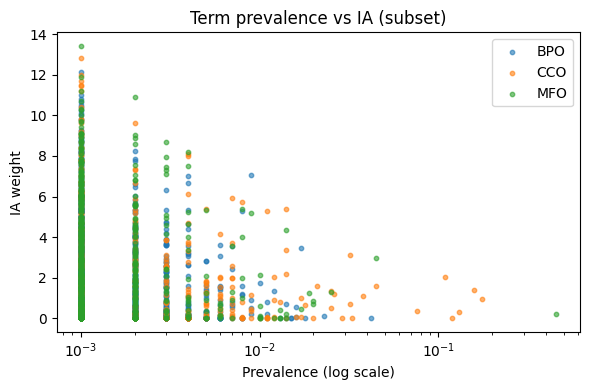

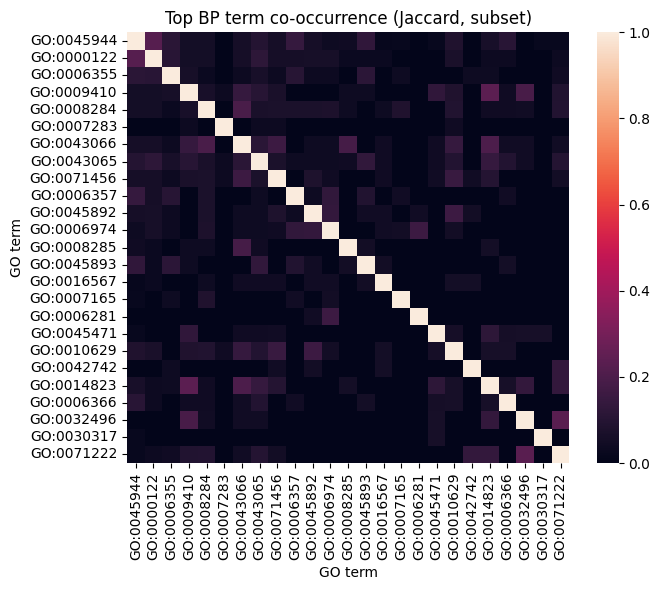

In [29]:
# IA vs prevalence
IA = pd.read_csv(IA_PATH, sep="\t", header=None, names=["go_id","ia"])
ia_map = IA.set_index("go_id")["ia"]

# prevalence among subset entries
term_counts = mini_terms.groupby(["go_id","aspect"])["entry"].nunique().reset_index(name="count")
n_prots = mini_tax["entry"].nunique()
term_counts["prev"] = term_counts["count"] / n_prots
term_counts["ia"] = term_counts["go_id"].map(ia_map)

plt.figure(figsize=(6,4))
for a, dfA in term_counts.dropna().groupby("aspect"):
    plt.scatter(dfA["prev"], dfA["ia"], s=10, alpha=0.6, label=a)
plt.xscale("log"); plt.xlabel("Prevalence (log scale)"); plt.ylabel("IA weight")
plt.title("Term prevalence vs IA (subset)"); plt.legend()
plt.tight_layout(); plt.show()

# Co-occurrence (Jaccard) among top-k BP terms
topk = 25
bp_terms = (term_counts[term_counts["aspect"]=="BPO"]
            .sort_values("count", ascending=False)
            .head(topk)["go_id"].tolist())

# build binary matrix: proteins × top BP terms
prot_list = sorted(mini_tax["entry"].unique())
idx = {p:i for i,p in enumerate(prot_list)}
jmat = np.zeros((topk, topk), dtype=float)
cols = {t:i for i,t in enumerate(bp_terms)}
# membership sets
members = {t: set(mini_terms[(mini_terms["aspect"]=="BPO") & (mini_terms["go_id"]==t)]["entry"]) for t in bp_terms}
for i, ti in enumerate(bp_terms):
    Si = members[ti]
    for j, tj in enumerate(bp_terms):
        Sj = members[tj]
        inter = len(Si & Sj)
        uni   = len(Si | Sj)
        jmat[i,j] = inter/uni if uni else 0.0

plt.figure(figsize=(7,6))
sns.heatmap(jmat, xticklabels=bp_terms, yticklabels=bp_terms)
plt.title("Top BP term co-occurrence (Jaccard, subset)")
plt.xlabel("GO term"); plt.ylabel("GO term")
plt.tight_layout(); plt.show()


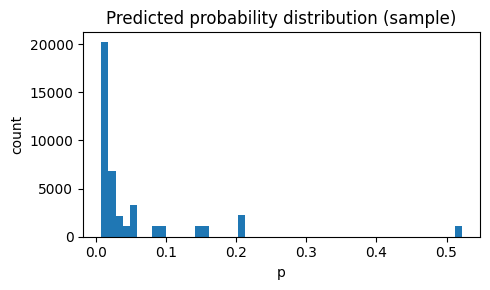

In [30]:
# Adjust path to your latest submission (gz or tsv)
SUB_PATH = os.path.join(DATA_DIR, "submission.tsv.gz")  # or .gz

# sample 500k lines efficiently
import gzip, random
sample_probs = []
read_fn = gzip.open if SUB_PATH.endswith(".gz") else open
with read_fn(SUB_PATH, "rt") as f:
    for i, line in enumerate(f):
        if random.random() < 5e-3:  # ~0.5% sample; tweak as needed
            try:
                _, _, p = line.strip().split("\t")
                sample_probs.append(float(p))
            except:
                pass
        if len(sample_probs) >= 500_000:
            break

plt.figure(figsize=(5,3))
plt.hist(sample_probs, bins=50)
plt.title("Predicted probability distribution (sample)")
plt.xlabel("p"); plt.ylabel("count")
plt.tight_layout(); plt.show()
